# Comparison of anycast latency between Cloudflare and Google

Cloudflare is anycast first CDN provider. They use anycast for majority of their services, especially for CDN. We used `https://cloudflare.com/cdn-cgi/trace`. Google uses anycast limitedly, mostly it powers Geo-DNS. However, `8.8.8.8` uses anycast, because it has http endpoint: `https://dns.google/`.

In [13]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("Imported libs")

Imported libs


## Data loading and preprocessing

In [14]:
cloudflare = pl.read_csv("all_combined.csv", ignore_errors=True)
cloudflare.head()

timestamp,balancerId,balancerIp,clientIpAccordingCloudflare,clientCountryAccordingCloudflare,balancerColocationCenter,targetDomain,scheme,httpVersion,tlsVersion,clientCountry,clientCity,clientAsn,clientNetwork,latencyTotal,latencyDNS,latencyTCP,latencyTLS,latencyFirstByte,latencyDownload
f64,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64
1.7690e9,"""107f211""","""104.16.133.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",84,14,3,46,15,6
1.7690e9,"""107f156""","""104.16.133.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",78,11,1,18,37,11
1.7690e9,"""107f211""","""104.16.132.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",23,2,1,13,5,2
1.7690e9,"""107f179""","""104.16.132.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",27,1,1,14,10,1
1.7690e9,"""107f174""","""104.16.132.229""","""185.32.190.187""","""PT""","""LIS""","""cloudflare.com""","""https""","""http/2""","""TLSv1.3""","""PT""","""Lisbon""",62416,"""SAMPLING LINE-SERVICOS E INTER…",29,2,0,18,7,2


In [16]:
google = pl.read_csv("google_dns.csv", ignore_errors=True, truncate_ragged_lines=True)
google.head()

timestamp,balancerId,balancerIp,clientIpAccordingCloudflare,clientCountryAccordingCloudflare,balancerColocationCenter,targetDomain,scheme,httpVersion,tlsVersion,clientCountry,clientCity,clientAsn,clientNetwork,httpCode,latencyTotal,latencyDNS,latencyTCP,latencyTLS,latencyFirstByte,latencyDownload
str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64
"""null""","""null""","""8.8.4.4""","""null""","""null""","""null""","""null""","""null""","""null""","""null""","""LV""","""Riga""",50053,"""VDSka hosting""",200,84,12,11,42,16,3
"""null""","""null""","""8.8.4.4""","""null""","""null""","""null""","""null""","""null""","""null""","""null""","""LV""","""Riga""",50053,"""VDSka hosting""",200,50,12,7,20,10,1
"""null""","""null""","""8.8.4.4""","""null""","""null""","""null""","""null""","""null""","""null""","""null""","""LV""","""Riga""",50053,"""VDSka hosting""",200,50,14,8,16,10,2
"""null""","""null""","""8.8.8.8""","""null""","""null""","""null""","""null""","""null""","""null""","""null""","""LV""","""Riga""",50053,"""VDSka hosting""",200,65,16,10,26,12,1
"""null""","""null""","""8.8.8.8""","""null""","""null""","""null""","""null""","""null""","""null""","""null""","""LV""","""Riga""",50053,"""VDSka hosting""",200,96,16,10,47,22,1


## Latency calculation

In [32]:
locationKey = ['clientCountry', 'clientCity', 'clientAsn']

def calculate_latency(df: pl.DataFrame) -> pl.DataFrame:
    return df.group_by(locationKey).agg(
        pl.col('latencyTotal').median().alias('latencyMedian'),
        pl.len().alias('measures')
    ).filter(pl.col('measures') >= 10)

google_latency = calculate_latency(google)
cloudflare_latency = calculate_latency(cloudflare)

In [33]:
compare_latency = (
    google_latency.join(cloudflare_latency,
    left_on=locationKey,
    right_on=locationKey,
    suffix="_cloudflare").with_columns(
        (pl.col('latencyMedian_cloudflare') - pl.col('latencyMedian')).alias('delta'),
        (pl.col('clientCountry') +
            pl.col('clientCity') +
            pl.col('clientAsn').cast(pl.String)
        ).alias('unique_id')
    ).sort('delta')
)
compare_latency.head()

clientCountry,clientCity,clientAsn,latencyMedian,measures,latencyMedian_cloudflare,measures_cloudflare,delta,unique_id
str,str,i64,f64,u32,f64,u32,f64,str
"""BR""","""Sao Leopoldo""",263648,4124.5,10,28.0,30,-4096.5,"""BRSao Leopoldo263648"""
"""BR""","""Sao Paulo""",396982,783.0,10,32.5,40,-750.5,"""BRSao Paulo396982"""
"""AU""","""Sydney""",396982,663.5,10,37.5,40,-626.0,"""AUSydney396982"""
"""HK""","""Tsuen Wan""",134677,470.0,20,36.0,79,-434.0,"""HKTsuen Wan134677"""
"""QA""","""Doha""",21859,549.5,10,127.0,2487,-422.5,"""QADoha21859"""


## Latency difference plot

We can visualize the difference in latencies sorted by it. 

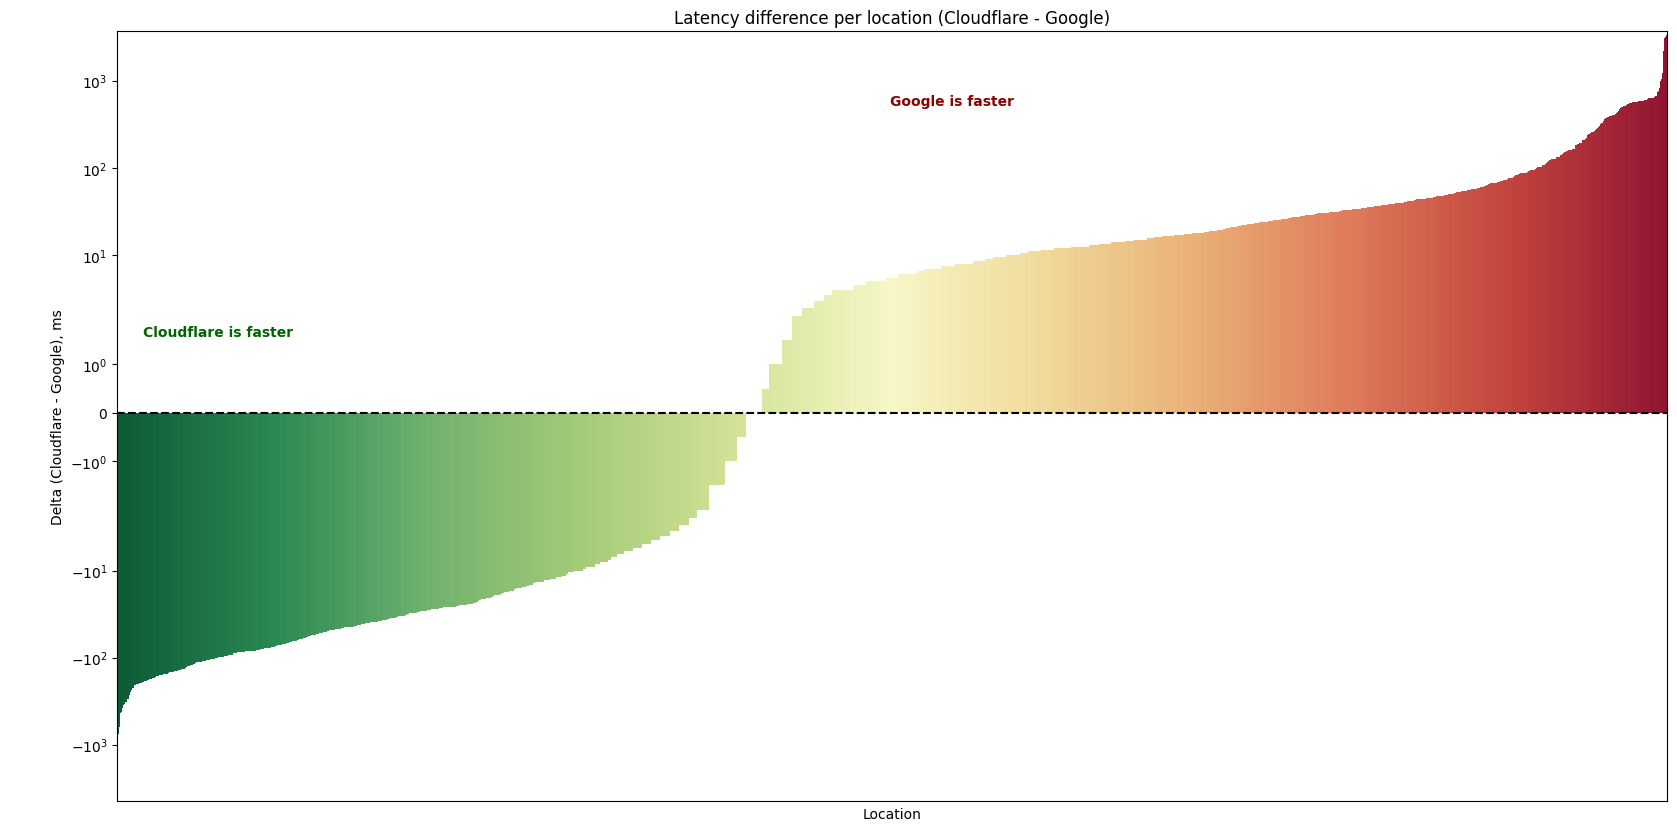

In [40]:
plt.figure(figsize=(20, 10))
sns.barplot(
    data=compare_latency, 
    x='unique_id', 
    y="delta",
    palette="RdYlGn_r",
    hue='unique_id',
    edgecolor="none",
    width=1
)
plt.yscale('symlog')
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.title("Latency difference per location (Cloudflare - Google)")
plt.xlabel("Location")
plt.ylabel("Delta (Cloudflare - Google), ms")

plt.text(0.02, 0.5, "Cloudflare is faster", transform=ax.transAxes, color='darkgreen', fontweight='bold')
plt.text(0.99, 0.8, "Google is faster", transform=ax.transAxes, color='darkred', fontweight='bold')

plt.xticks([])
plt.show()

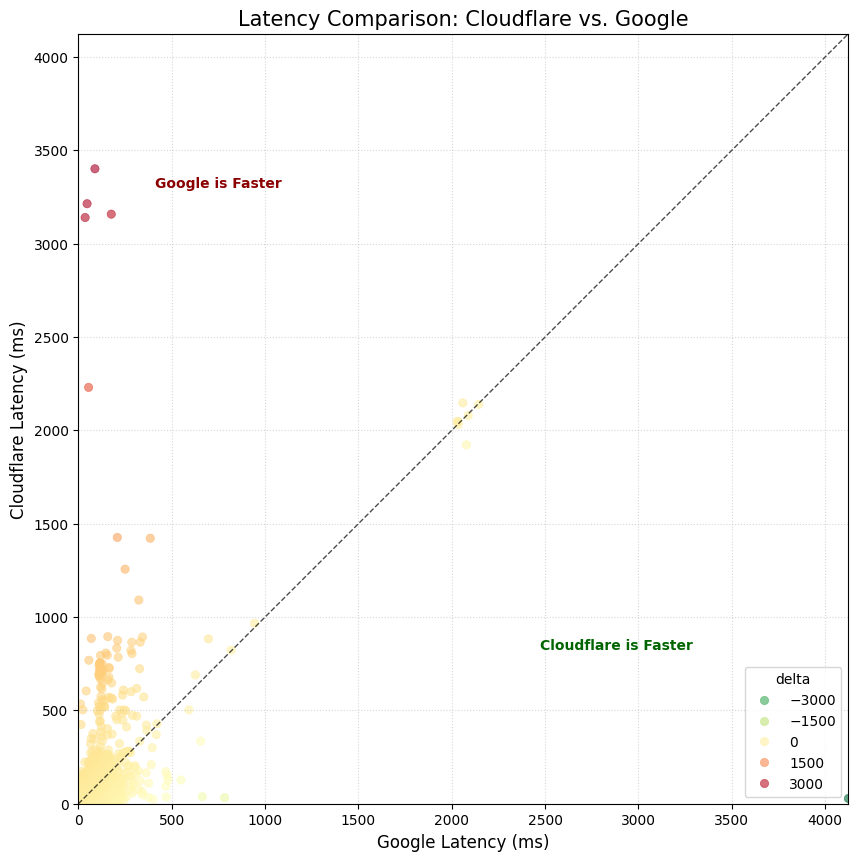

In [ ]:
plt.figure(figsize=(10, 10))
ax = plt.gca()

sns.scatterplot(
    data=compare_latency,
    x='latencyMedian',
    y='latencyMedian_cloudflare',
    alpha=0.6,
    edgecolor=None,
    hue='delta',
    palette='RdYlGn_r' # Red = Google faster, Green = Cloudflare faster
)

max_val = max(compare_latency['latencyMedian'].max(), 
              compare_latency['latencyMedian_cloudflare'].max())
min_val = 0

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
ax.set_aspect('equal', adjustable='box')

plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1, alpha=0.7)

plt.title("Latency Comparison: Cloudflare vs. Google", fontsize=15)
plt.xlabel("Google Latency (ms)", fontsize=12)
plt.ylabel("Cloudflare Latency (ms)", fontsize=12)

plt.text(max_val*0.1, max_val*0.8, "Google is Faster", color='darkred', fontweight='bold')
plt.text(max_val*0.6, max_val*0.2, "Cloudflare is Faster", color='darkgreen', fontweight='bold')

plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.show()